In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

import nltk
import os
# Ensure a local nltk_data directory exists and is used
local_nltk_dir = os.path.join(os.getcwd(), 'nltk_data')
if not os.path.exists(local_nltk_dir):
    os.makedirs(local_nltk_dir, exist_ok=True)
# Prepend our local dir so downloads land there
nltk.data.path.insert(0, local_nltk_dir)

# Download required NLTK resources if not already present
for pkg in ['stopwords', 'wordnet']:
    try:
        nltk.data.find(f'corpora/{pkg}')
    except LookupError:
        try:
            nltk.download(pkg, download_dir=local_nltk_dir)
        except Exception:
            pass

from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

[nltk_data] Downloading package wordnet to c:\Users\a00548169\OneDrive
[nltk_data]     - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\
[nltk_data]     data\2014-2025\UK\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [7]:
df = pd.read_csv("UK_research.csv", encoding="utf-8")
# Drop 'Unnamed: 0' column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns="Unnamed: 0")

# Continue with date parsing and cleanup
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')

# Drop rows with missing critical values (Date or ETF)
df = df.dropna(subset=[c for c in ['Date', 'ETF'] if c in df.columns]).reset_index(drop=True)

# Reset index to start from 1
df.index = df.index + 1

df

,Index,Date,Headline,gold,oil,bond,cad,cny,eur,jpy,mxn,vix,bitcoin,ETF
1,2,2014-01-02,China-Japan tensions: Chef crashes balloon nea...,1225.2,95.44,3.028,1.7550,9.9557,1.2035,172.34,21.6432,13.46,856.9,6717.91
2,3,2014-01-03,'What's normal at your work that would blow an...,1238.6,93.96,3.024,1.7450,9.9345,1.2081,172.04,21.5114,13.21,884.3,6730.67
3,4,2014-01-04,'What's normal at your work that would blow an...,1238.6,93.96,3.029,1.7450,9.9345,1.2081,172.04,21.5114,13.21,924.7,6730.67
4,5,2014-01-05,Outrage over commercialisation plans for BBC W...,1238.6,93.96,3.029,1.7450,9.9345,1.2081,172.04,21.5114,13.21,1014.7,6730.67
5,6,2014-01-06,Shia LaBeouf copies rapper Gucci Mane and feud...,1238.0,93.43,2.974,1.7475,9.9297,1.2038,170.95,21.4691,13.29,1012.7,6730.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4378,4379,2025-12-27,UK weather: Will it snow in the New Year Tempe...,4552.7,56.74,4.508,1.8457,9.4587,1.1467,211.36,24.1797,10.96,87850.8,9870.68
4379,4380,2025-12-28,Babylons Diego Calva on playing a villain in T...,4552.7,56.74,4.508,1.8457,9.4587,1.1467,211.36,24.1797,10.96,87904.3,9870.68
4380,4381,2025-12-29,World Darts Championship 2026 schedule and res...,4327.0,58.08,4.490,1.8496,9.4648,1.1475,210.83,24.2865,10.96,87217.7,9866.53
4381,4382,2025-12-30,Bank robbers drill hole in wall to steal milli...,4386.3,57.95,4.497,1.8446,9.4224,1.1464,210.65,24.2362,10.96,88469.6,9940.71


In [8]:
from sklearn.preprocessing import StandardScaler

# Scaler for features
scaler = StandardScaler()

# Get numeric columns to scale (excluding Date if present)
columns_to_scale = [col for col in ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'vix'] if col in df.columns]

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])


df

,Index,Date,Headline,gold,oil,bond,cad,cny,eur,jpy,mxn,vix,bitcoin,ETF
1,2,2014-01-02,China-Japan tensions: Chef crashes balloon nea...,-0.771498,1.655113,0.650477,0.061887,1.719087,0.257216,0.443553,-1.484378,0.290690,-0.780258,6717.91
2,3,2014-01-03,'What's normal at your work that would blow an...,-0.751103,1.575438,0.647669,-0.033663,1.678794,0.319963,0.429664,-1.547175,0.213507,-0.779383,6730.67
3,4,2014-01-04,'What's normal at your work that would blow an...,-0.751103,1.575438,0.651179,-0.033663,1.678794,0.319963,0.429664,-1.547175,0.213507,-0.778093,6730.67
4,5,2014-01-05,Outrage over commercialisation plans for BBC W...,-0.751103,1.575438,0.651179,-0.033663,1.678794,0.319963,0.429664,-1.547175,0.213507,-0.775219,6730.67
5,6,2014-01-06,Shia LaBeouf copies rapper Gucci Mane and feud...,-0.752016,1.546905,0.612575,-0.009776,1.669671,0.261308,0.379203,-1.567329,0.238205,-0.775282,6730.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4378,4379,2025-12-27,UK weather: Will it snow in the New Year Tempe...,4.293144,-0.428286,1.689257,0.928524,0.774482,-0.517577,2.249973,-0.275841,-0.481138,1.997649,9870.68
4379,4380,2025-12-28,Babylons Diego Calva on playing a villain in T...,4.293144,-0.428286,1.689257,0.928524,0.774482,-0.517577,2.249973,-0.275841,-0.481138,1.999358,9870.68
4380,4381,2025-12-29,World Darts Championship 2026 schedule and res...,3.949616,-0.356148,1.676623,0.965789,0.786075,-0.506664,2.225437,-0.224955,-0.481138,1.977433,9866.53
4381,4382,2025-12-30,Bank robbers drill hole in wall to steal milli...,4.039874,-0.363146,1.681536,0.918014,0.705489,-0.521669,2.217104,-0.248921,-0.481138,2.017409,9940.71


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4382 entries, 1 to 4382
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Index     4382 non-null   int64         
 1   Date      4382 non-null   datetime64[us]
 2   Headline  4288 non-null   str           
 3   gold      4382 non-null   float64       
 4   oil       4382 non-null   float64       
 5   bond      4382 non-null   float64       
 6   cad       4382 non-null   float64       
 7   cny       4382 non-null   float64       
 8   eur       4382 non-null   float64       
 9   jpy       4382 non-null   float64       
 10  mxn       4382 non-null   float64       
 11  vix       4382 non-null   float64       
 12  bitcoin   4382 non-null   float64       
 13  ETF       4382 non-null   float64       
dtypes: datetime64[us](1), float64(11), int64(1), str(1)
memory usage: 479.4 KB


In [10]:
df.describe()

,Index,Date,gold,oil,bond,cad,cny,eur,jpy,mxn,vix,bitcoin,ETF
count,4382.000000,4382,4.382000e+03,4.382000e+03,4.382000e+03,4.382000e+03,4.382000e+03,4.382000e+03,4.382000e+03,4.382000e+03,4.382000e+03,4.382000e+03,4382.000000
mean,2192.500000,2020-01-01 12:00:00,3.113286e-16,3.113286e-16,2.594405e-17,9.080418e-16,9.339859e-16,-1.063706e-15,4.151048e-16,-2.853846e-16,4.151048e-16,-1.556643e-16,7256.610349
min,2.000000,2014-01-02 00:00:00,-1.038771e+00,-2.859995e+00,-1.422169e+00,-2.687084e+00,-2.712765e+00,-1.645665e+00,-1.729060e+00,-1.973225e+00,-1.953785e+00,-8.040566e-01,4993.890000
25%,1097.250000,2017-01-01 06:00:00,-7.085994e-01,-7.593691e-01,-7.466116e-01,-5.818809e-01,-6.327330e-01,-6.273849e-01,-8.610332e-01,-8.033279e-01,-4.811378e-01,-7.778027e-01,6758.595000
50%,2192.500000,2020-01-01 12:00:00,-3.113047e-01,-8.966656e-02,-3.883028e-01,-2.137749e-01,-1.812421e-01,-2.556752e-01,-2.017961e-01,2.430464e-02,-4.811378e-01,-4.984942e-01,7257.480000
75%,3287.750000,2022-12-31 18:00:00,2.916199e-01,6.218924e-01,9.584260e-01,5.907552e-01,5.908347e-01,1.627540e-01,9.367072e-01,6.211883e-01,1.270623e-01,4.615323e-01,7589.365000
max,4383.000000,2025-12-31 00:00:00,4.293144e+00,2.965447e+00,1.953865e+00,3.317272e+00,3.059210e+00,3.503708e+00,2.254140e+00,2.927391e+00,6.162754e+00,3.175127e+00,9940.710000
std,1265.118769,NaN,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,791.289903


In [11]:
# Ensure stopwords are available, with fallback to downloading if necessary
try:
    stopwords_object = stopwords.words('english')
except LookupError:
    import nltk
    nltk.download('stopwords')
    stopwords_object = stopwords.words('english')

# Use RegexpTokenizer to avoid punkt dependency
tokenizer = RegexpTokenizer(r"[a-zA-Z]+")

# Preprocessing
if 'Headline' in df.columns:
    df["Headline"] = df["Headline"].astype(str).str.lower()


def preprocessing_text(data):
    if pd.isna(data):
        return ''

    text = re.sub("[^a-zA-Z]"," ", str(data))

    tokens = tokenizer.tokenize(text)

    word_tokens = [w for w in tokens if w not in stopwords_object]

    stemmer = PorterStemmer()
    stem_words = [stemmer.stem(w) for w in word_tokens]

    lemmer = WordNetLemmatizer()
    lem_words = [lemmer.lemmatize(w) for w in stem_words]

    return " ".join(lem_words)

# Apply preprocessing and create Headline2
if 'Headline' in df.columns:
    df["Headline2"] = df["Headline"].apply(preprocessing_text)
    df
else:
    print('No Headline column found')

# If another cell applies preprocessing again, guard it with try/except to avoid duplicate errors
try:
    if 'Headline2' not in df.columns and 'Headline' in df.columns:
        df["Headline2"] = df["Headline"].apply(preprocessing_text)
except Exception as e:
    print('Preprocessing skipped due to:', e)

df

,Index,Date,Headline,gold,oil,bond,cad,cny,eur,jpy,mxn,vix,bitcoin,ETF,Headline2
1,2,2014-01-02,china-japan tensions: chef crashes balloon nea...,-0.771498,1.655113,0.650477,0.061887,1.719087,0.257216,0.443553,-1.484378,0.290690,-0.780258,6717.91,china japan tension chef crash balloon near di...
2,3,2014-01-03,'what's normal at your work that would blow an...,-0.751103,1.575438,0.647669,-0.033663,1.678794,0.319963,0.429664,-1.547175,0.213507,-0.779383,6730.67,normal work would blow anyon el mind cuban all...
3,4,2014-01-04,'what's normal at your work that would blow an...,-0.751103,1.575438,0.651179,-0.033663,1.678794,0.319963,0.429664,-1.547175,0.213507,-0.778093,6730.67,normal work would blow anyon el mind outrag co...
4,5,2014-01-05,outrage over commercialisation plans for bbc w...,-0.751103,1.575438,0.651179,-0.033663,1.678794,0.319963,0.429664,-1.547175,0.213507,-0.775219,6730.67,outrag commercialis plan bbc world servic dead...
5,6,2014-01-06,shia labeouf copies rapper gucci mane and feud...,-0.752016,1.546905,0.612575,-0.009776,1.669671,0.261308,0.379203,-1.567329,0.238205,-0.775282,6730.73,shia labeouf copi rapper gucci mane feud lena ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4378,4379,2025-12-27,uk weather: will it snow in the new year tempe...,4.293144,-0.428286,1.689257,0.928524,0.774482,-0.517577,2.249973,-0.275841,-0.481138,1.997649,9870.68,uk weather snow new year temperatur set dip ne...
4379,4380,2025-12-28,babylons diego calva on playing a villain in t...,4.293144,-0.428286,1.689257,0.928524,0.774482,-0.517577,2.249973,-0.275841,-0.481138,1.999358,9870.68,babylon diego calva play villain night manag s...
4380,4381,2025-12-29,world darts championship 2026 schedule and res...,3.949616,-0.356148,1.676623,0.965789,0.786075,-0.506664,2.225437,-0.224955,-0.481138,1.977433,9866.53,world dart championship schedul result luke li...
4381,4382,2025-12-30,bank robbers drill hole in wall to steal milli...,4.039874,-0.363146,1.681536,0.918014,0.705489,-0.521669,2.217104,-0.248921,-0.481138,2.017409,9940.71,bank robber drill hole wall steal million safe...


In [12]:
df["Headline2"] = df["Headline"].apply(preprocessing_text)
df

,Index,Date,Headline,gold,oil,bond,cad,cny,eur,jpy,mxn,vix,bitcoin,ETF,Headline2
1,2,2014-01-02,china-japan tensions: chef crashes balloon nea...,-0.771498,1.655113,0.650477,0.061887,1.719087,0.257216,0.443553,-1.484378,0.290690,-0.780258,6717.91,china japan tension chef crash balloon near di...
2,3,2014-01-03,'what's normal at your work that would blow an...,-0.751103,1.575438,0.647669,-0.033663,1.678794,0.319963,0.429664,-1.547175,0.213507,-0.779383,6730.67,normal work would blow anyon el mind cuban all...
3,4,2014-01-04,'what's normal at your work that would blow an...,-0.751103,1.575438,0.651179,-0.033663,1.678794,0.319963,0.429664,-1.547175,0.213507,-0.778093,6730.67,normal work would blow anyon el mind outrag co...
4,5,2014-01-05,outrage over commercialisation plans for bbc w...,-0.751103,1.575438,0.651179,-0.033663,1.678794,0.319963,0.429664,-1.547175,0.213507,-0.775219,6730.67,outrag commercialis plan bbc world servic dead...
5,6,2014-01-06,shia labeouf copies rapper gucci mane and feud...,-0.752016,1.546905,0.612575,-0.009776,1.669671,0.261308,0.379203,-1.567329,0.238205,-0.775282,6730.73,shia labeouf copi rapper gucci mane feud lena ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4378,4379,2025-12-27,uk weather: will it snow in the new year tempe...,4.293144,-0.428286,1.689257,0.928524,0.774482,-0.517577,2.249973,-0.275841,-0.481138,1.997649,9870.68,uk weather snow new year temperatur set dip ne...
4379,4380,2025-12-28,babylons diego calva on playing a villain in t...,4.293144,-0.428286,1.689257,0.928524,0.774482,-0.517577,2.249973,-0.275841,-0.481138,1.999358,9870.68,babylon diego calva play villain night manag s...
4380,4381,2025-12-29,world darts championship 2026 schedule and res...,3.949616,-0.356148,1.676623,0.965789,0.786075,-0.506664,2.225437,-0.224955,-0.481138,1.977433,9866.53,world dart championship schedul result luke li...
4381,4382,2025-12-30,bank robbers drill hole in wall to steal milli...,4.039874,-0.363146,1.681536,0.918014,0.705489,-0.521669,2.217104,-0.248921,-0.481138,2.017409,9940.71,bank robber drill hole wall steal million safe...


## **TF-IDF**

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [14]:
tfidf_result = tfidf.fit_transform(df["Headline2"])
df["tfidf_Headline"] = list(tfidf_result.toarray())

In [15]:
# Convert tfidf_Headline to proper format for modeling
tfidf_arrays = np.array(df['tfidf_Headline'].tolist())

# Get numeric features
numeric_features = ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'vix', 'bitcoin']
numeric_features = [c for c in numeric_features if c in df.columns]

# Combine tfidf features with numeric features
X = np.hstack([tfidf_arrays, df[numeric_features].values])
y = df["ETF"].values  # Already scaled

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **TF-IDF + Random Forest**

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

rf = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_split=2, random_state=42)
rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

# Inverse transform predictions and actual values to original scale
rf_predictions_original = etf_scaler.inverse_transform(rf_predictions.reshape(-1, 1)).flatten()
y_test_original = etf_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

rf_rmse = np.sqrt(mean_squared_error(y_test_original, rf_predictions_original))
print(f"Random Forest RMSE: {rf_rmse}")

rf_mae = mean_absolute_error(y_test_original, rf_predictions_original)
print(f"Random Forest MAE: {rf_mae}")

rf_mape = mean_absolute_percentage_error(y_test_original, rf_predictions_original)
print(f"Random Forest MAPE: {rf_mape}")

r2 = r2_score(y_test_original, rf_predictions_original)
print(f'Random Forest R제곱: {r2}')

NameError: name 'etf_scaler' is not defined

In [ ]:
# Random Forest feature importances
# X_train is a numpy array (tfidf + numeric features combined)
# We cannot use .columns, so we'll skip detailed feature names
print(f"\nTotal number of features: {len(rf.feature_importances_)}")
print(f"Top 10 feature importances: {sorted(rf.feature_importances_, reverse=True)[:10]}")


Total number of features: 27361
Top 10 feature importances: [0.6010491148870607, 0.19965817201952946, 0.08226411091865898, 0.044214930908009924, 0.01815735265259505, 0.018090372340262093, 0.01117827017571435, 0.008655902153417756, 0.005175352843714516, 0.004124316977815163]


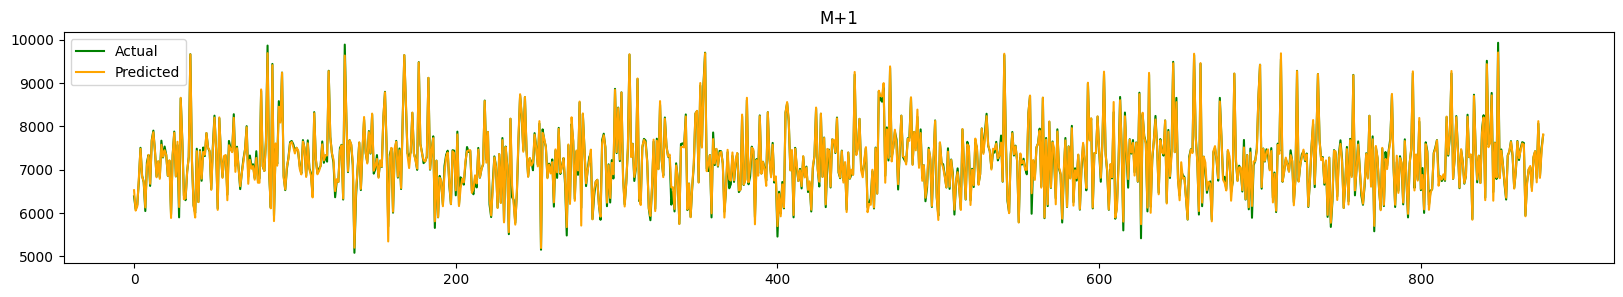

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 3))
plt.plot(y_test, label='Actual', color='green')
plt.plot(rf_predictions, label='Predicted', color='orange', linestyle='-')
plt.title('M+1')
plt.legend()
plt.show()

### **TF-IDF + LightGBM**

In [ ]:
!pip install lightgbm

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# TF-IDF 데이터 사용 (이미 준비된 X_train, X_test, y_train, y_test 사용)
# LightGBM 모델 생성
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=20,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

# 모델 학습
lgb_model.fit(X_train, y_train)

# 예측
lgb_predictions = lgb_model.predict(X_test)

# 평가
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_predictions))
print(f"TF-IDF + LightGBM RMSE: {lgb_rmse:.4f}")

lgb_mae = mean_absolute_error(y_test, lgb_predictions)
print(f"TF-IDF + LightGBM MAE: {lgb_mae:.4f}")

lgb_mape = mean_absolute_percentage_error(y_test, lgb_predictions)
print(f"TF-IDF + LightGBM MAPE: {lgb_mape:.4f} ({lgb_mape*100:.2f}%)")

lgb_r2 = r2_score(y_test, lgb_predictions)
print(f'TF-IDF + LightGBM R²: {lgb_r2:.4f} ({lgb_r2*100:.2f}%)')

TF-IDF + LightGBM RMSE: 85.3375
TF-IDF + LightGBM MAE: 62.6729
TF-IDF + LightGBM MAPE: 0.0089 (0.89%)
TF-IDF + LightGBM R²: 0.9884 (98.84%)


c:\Users\a00548169\OneDrive - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\data\2014-2025\UK\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# LightGBM 특성 중요도
lgb_feature_importances = lgb_model.feature_importances_

# Numeric features의 중요도
numeric_importances = lgb_feature_importances[tfidf_arrays.shape[1]:]
print(f"\nNumeric Features 중요도:")
for feature, importance in zip(numeric_features, numeric_importances):
    print(f"  {feature}: {importance:.2f}")


Numeric Features 중요도:
  gold: 206.00
  oil: 178.00
  bond: 123.00
  cad: 139.00
  cny: 128.00
  eur: 129.00
  jpy: 120.00
  mxn: 209.00
  vix: 129.00
  bitcoin: 147.00


### **TF-IDF + BILSTM**

In [ ]:
from tensorflow import keras
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Bidirectional
from keras.layers import PReLU

# X and y are already defined as numpy arrays from previous cells
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Reshape for LSTM (X is already numpy array)
X_lstm_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
y_lstm_train = np.reshape(y_train, (y_train.shape[0], 1))

X_lstm_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))
y_lstm_val = np.reshape(y_val, (y_val.shape[0], 1))

X_lstm_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
y_lstm_test = np.reshape(y_test, (y_test.shape[0], 1))

lstm_model = Sequential()
lstm_model.add(Bidirectional(LSTM(392, return_sequences=False), input_shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])))
lstm_model.add(Dense(256))
lstm_model.add(PReLU())
lstm_model.add(Dense(64))
lstm_model.add(PReLU())
lstm_model.add(Dense(1, activation='linear'))
lstm_model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mape'])

c:\Users\a00548169\OneDrive - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\data\2014-2025\UK\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 784)            │     1,235,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_8 (PReLU)               │ (None, 256)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_9 (PReLU)               │ (None, 64)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,453,377 (5.54 MB)

 Trainable params: 1,453,377 (5.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

history = lstm_model.fit(X_lstm_train, y_lstm_train, epochs=300, batch_size=32,
                         validation_data=(X_lstm_val, y_lstm_val),verbose=1)

lstm_predictions = lstm_model.predict(X_lstm_test)

lstm_rmse = np.sqrt(mean_squared_error(y_lstm_test, lstm_predictions))
print(f"BILSTM RMSE: {lstm_rmse}")

lstm_mae = mean_absolute_error(y_lstm_test, lstm_predictions)
print(f"BILSTM MAE: {lstm_mae}")

lstm_mape = mean_absolute_percentage_error(y_lstm_test, lstm_predictions)
print(f"BILSTM MAPE: {lstm_mape}")

r2 = r2_score(y_lstm_test, lstm_predictions)
print(f'BILSTM R제곱: {r2}')

Epoch 1/300


## **Hybrid (TF-IDF + RF + BiLSTM)**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# Step 1: Random Forest로 피처 중요도 추출
# 가능한 모든 수치 특성 후보
candidate_features = ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'vix']
# 실제 존재하는 특성만 선택
available_features = [col for col in candidate_features if col in df.columns]
print(f"Available features: {available_features}")

X_all = df[available_features]
y = df["ETF"].values

# RF 학습
rf_hybrid = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_split=2, random_state=42)
rf_hybrid.fit(X_all, y)

# 피처 중요도 추출
importances = pd.Series(rf_hybrid.feature_importances_, index=X_all.columns)
print("\nFeature Importances:")
print(importances.sort_values(ascending=False))

# 상위 5개 피처 선택
top5_features = importances.sort_values(ascending=False).head(5).index.tolist()
print(f"\nTop 5 Features: {top5_features}")

# Step 2: 상위 5개 피처로 BiLSTM 학습
X_top5 = df[top5_features]
y = df["ETF"].values

X_train, X_temp, y_train, y_temp = train_test_split(X_top5, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_lstm_train = np.reshape(X_train.values, (X_train.shape[0], X_train.shape[1], 1))
y_lstm_train = np.reshape(y_train, (y_train.shape[0], 1))

X_lstm_val = np.reshape(X_val.values, (X_val.shape[0], X_val.shape[1], 1))
y_lstm_val = np.reshape(y_val, (y_val.shape[0], 1))

X_lstm_test = np.reshape(X_test.values, (X_test.shape[0], X_test.shape[1], 1))
y_lstm_test = np.reshape(y_test, (y_test.shape[0], 1))

# BiLSTM 모델 생성
hybrid_model = Sequential()
hybrid_model.add(Bidirectional(LSTM(128, return_sequences=False), input_shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])))
hybrid_model.add(Dense(128))
hybrid_model.add(PReLU())
hybrid_model.add(Dense(64))
hybrid_model.add(PReLU())
hybrid_model.add(Dense(1, activation='linear'))
hybrid_model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mape'])

print("\n=== Hybrid BiLSTM Model (Top 5 Features) ===")
hybrid_model.summary()

# 학습
history = hybrid_model.fit(X_lstm_train, y_lstm_train, epochs=300, batch_size=32,
                         validation_data=(X_lstm_val, y_lstm_val), verbose=1)

# 예측 및 평가
hybrid_predictions = hybrid_model.predict(X_lstm_test)

hybrid_rmse = np.sqrt(mean_squared_error(y_lstm_test, hybrid_predictions))
print(f"\nHybrid RMSE: {hybrid_rmse}")

hybrid_mae = mean_absolute_error(y_lstm_test, hybrid_predictions)
print(f"Hybrid MAE: {hybrid_mae}")

hybrid_mape = mean_absolute_percentage_error(y_lstm_test, hybrid_predictions)
print(f"Hybrid MAPE: {hybrid_mape}")

r2 = r2_score(y_lstm_test, hybrid_predictions)
print(f'Hybrid R제곱: {r2}')


Available features: ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'vix']

Feature Importances:
gold       0.590862
oil        0.202673
bitcoin    0.089844
mxn        0.041933
eur        0.022909
vix        0.020816
cny        0.009984
bond       0.009788
cad        0.005970
jpy        0.005221
dtype: float64

Top 5 Features: ['gold', 'oil', 'bitcoin', 'mxn', 'eur']

=== Hybrid BiLSTM Model (Top 5 Features) ===


c:\Users\a00548169\OneDrive - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\data\2014-2025\UK\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       133,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_2 (PReLU)               │ (None, 128)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_3 (PReLU)               │ (None, 64)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,529 (681.75 KB)

 Trainable params: 174,529 (681.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 43958832.0000 - mape: 89.2601 - val_loss: 9342073.0000 - val_mape: 40.2598
Epoch 2/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1260714.6250 - mape: 11.0598 - val_loss: 657863.3125 - val_mape: 8.8182
Epoch 3/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 615624.8125 - mape: 8.0690 - val_loss: 633854.0000 - val_mape: 8.5341
Epoch 4/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 604075.8750 - mape: 7.9772 - val_loss: 604051.2500 - val_mape: 8.3296
Epoch 5/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 476597.1250 - mape: 6.9808 - val_loss: 408971.0625 - val_mape: 7.0241
Epoch 6/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 304160.1250 - mape: 6.0996 - val_loss: 211958.0312 - val_mape: 5.1867
Epoch 7/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 157090.2188 - mape: 4.3681 - val_loss: 129152.9219 - val_mape: 4.0805
Epoch 8/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 103825.6719 - m

## **TF-IDF + LightGBM**

In [ ]:
!pip install --quiet lightgbm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import lightgbm as lgb
import numpy as np

# TF-IDF 벡터화
# 전처리된 헤드라인 사용 (preprocessing_text 함수로 처리된 데이터)
if 'cleaned_headline' in df.columns:
    headline_col = 'cleaned_headline'
else:
    headline_col = 'Headline'

tfidf_vectorizer = TfidfVectorizer(max_features=500, min_df=2, max_df=0.8)
tfidf_features = tfidf_vectorizer.fit_transform(df[headline_col].fillna('')).toarray()
print(f"TF-IDF 특성 shape: {tfidf_features.shape}")

# 금융 지표 특성
financial_features = ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'vix']
financial_features = [c for c in financial_features if c in df.columns]
financial_data = df[financial_features].values
print(f"금융 지표 shape: {financial_data.shape}")

# TF-IDF + 금융 지표 결합
X = np.hstack([tfidf_features, financial_data])
y = df["ETF"].values
print(f"최종 특성 shape: {X.shape}")

# 훈련/테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

# LightGBM 모델 훈련
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'verbose': -1,
    'random_state': 20
}

lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train)

print("\nLightGBM 모델 훈련 중...")
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=200,
    valid_sets=[lgb_train, lgb_eval],
    valid_names=['train', 'test']
)

# 예측 및 평가
lgb_predictions = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_predictions))
print(f"\nTF-IDF + LightGBM RMSE: {lgb_rmse:.4f}")

lgb_mae = mean_absolute_error(y_test, lgb_predictions)
print(f"TF-IDF + LightGBM MAE: {lgb_mae:.4f}")

lgb_mape = mean_absolute_percentage_error(y_test, lgb_predictions)
print(f"TF-IDF + LightGBM MAPE: {lgb_mape:.4f}")

lgb_r2 = r2_score(y_test, lgb_predictions)
print(f'TF-IDF + LightGBM R제곱: {lgb_r2:.4f}')

# 특성 중요도 확인
print("\n상위 10개 중요 특성:")
feature_importance = lgb_model.feature_importance(importance_type='gain')
feature_names = [f'tfidf_{i}' for i in range(tfidf_features.shape[1])] + financial_features
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)
print(importance_df.head(10))

TF-IDF 특성 shape: (4382, 500)
금융 지표 shape: (4382, 10)
최종 특성 shape: (4382, 510)

LightGBM 모델 훈련 중...

TF-IDF + LightGBM RMSE: 76.9502
TF-IDF + LightGBM MAE: 59.3774
TF-IDF + LightGBM MAPE: 0.0084
TF-IDF + LightGBM R제곱: 0.9912

상위 10개 중요 특성:
     feature    importance
500     gold  1.279083e+10
501      oil  4.209874e+09
508  bitcoin  2.074975e+09
507      mxn  1.114750e+09
509      vix  4.429749e+08
504      cny  3.473022e+08
503      cad  3.105092e+08
502     bond  2.792938e+08
505      eur  1.654462e+08
506      jpy  1.033674e+08


## **FinBERT**

In [ ]:
!pip install pandas transformers torch

In [ ]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('./finbert')
model = BertModel.from_pretrained('./finbert')

df['headline']=df["Headline"]

c:\Users\a00548169\OneDrive - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\data\2014-2025\UK\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 625.12it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: ./finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Tokenize with max_length to avoid exceeding BERT's limit
tokenized_headlines = df['headline'].apply((lambda x: tokenizer.encode(x, add_special_tokens=True, max_length=512, truncation=True)))

max_len = min(512, max(map(len, tokenized_headlines)))  # Cap at 512
padded_headlines = torch.tensor([i + [0]*(max_len-len(i)) for i in tokenized_headlines])

In [ ]:
attention_mask = (padded_headlines != 0).float()

In [ ]:
# Process in batches to avoid memory issues
batch_size = 32
all_outputs = []

with torch.no_grad():
    for i in range(0, len(padded_headlines), batch_size):
        batch = padded_headlines[i:i+batch_size]
        batch_mask = attention_mask[i:i+batch_size]
        outputs = model(batch, attention_mask=batch_mask)
        all_outputs.append(outputs.last_hidden_state[:, 0, :])
        
# Concatenate all batch outputs
outputs_concat = torch.cat(all_outputs, dim=0)

In [ ]:
finbert_embeddings = outputs_concat

In [ ]:
finbert_embeddings.shape

torch.Size([4382, 768])

In [ ]:
finbert_headline = finbert_embeddings.tolist()
df['finbert_headline'] = finbert_headline
df

,Index,Date,Headline,gold,oil,bond,cad,cny,eur,jpy,mxn,vix,bitcoin,ETF,Headline2,tfidf_Headline,headline,finbert_headline
0,2,2014-01-02,china-japan tensions: chef crashes balloon nea...,-0.771498,1.655113,0.650477,0.061887,1.719087,0.257216,0.443553,-1.484378,0.290690,-0.780258,6717.91,china japan tension chef crash balloon near di...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",china-japan tensions: chef crashes balloon nea...,"[-0.2995907664299011, 0.7144534587860107, 0.27..."
1,3,2014-01-03,'what's normal at your work that would blow an...,-0.751103,1.575438,0.647669,-0.033663,1.678794,0.319963,0.429664,-1.547175,0.213507,-0.779383,6730.67,normal work would blow anyon el mind cuban all...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",'what's normal at your work that would blow an...,"[0.048316288739442825, 0.7057263851165771, 0.1..."
2,4,2014-01-04,'what's normal at your work that would blow an...,-0.751103,1.575438,0.651179,-0.033663,1.678794,0.319963,0.429664,-1.547175,0.213507,-0.778093,6730.67,normal work would blow anyon el mind outrag co...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",'what's normal at your work that would blow an...,"[0.06046866998076439, 0.5356607437133789, -0.0..."
3,5,2014-01-05,outrage over commercialisation plans for bbc w...,-0.751103,1.575438,0.651179,-0.033663,1.678794,0.319963,0.429664,-1.547175,0.213507,-0.775219,6730.67,outrag commercialis plan bbc world servic dead...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",outrage over commercialisation plans for bbc w...,"[-0.02589227631688118, 0.7625051736831665, -0...."
4,6,2014-01-06,shia labeouf copies rapper gucci mane and feud...,-0.752016,1.546905,0.612575,-0.009776,1.669671,0.261308,0.379203,-1.567329,0.238205,-0.775282,6730.73,shia labeouf copi rapper gucci mane feud lena ...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",shia labeouf copies rapper gucci mane and feud...,"[-0.2724660634994507, 0.02354404889047146, 0.3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4377,4379,2025-12-27,uk weather: will it snow in the new year tempe...,4.293144,-0.428286,1.689257,0.928524,0.774482,-0.517577,2.249973,-0.275841,-0.481138,1.997649,9870.68,uk weather snow new year temperatur set dip ne...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",uk weather: will it snow in the new year tempe...,"[0.07166602462530136, -0.13848280906677246, 0...."
4378,4380,2025-12-28,babylons diego calva on playing a villain in t...,4.293144,-0.428286,1.689257,0.928524,0.774482,-0.517577,2.249973,-0.275841,-0.481138,1.999358,9870.68,babylon diego calva play villain night manag s...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",babylons diego calva on playing a villain in t...,"[-0.22020258009433746, 0.183224156498909, -1.0..."
4379,4381,2025-12-29,world darts championship 2026 schedule and res...,3.949616,-0.356148,1.676623,0.965789,0.786075,-0.506664,2.225437,-0.224955,-0.481138,1.977433,9866.53,world dart championship schedul result luke li...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",world darts championship 2026 schedule and res...,"[-0.6971954107284546, 0.3833232522010803, 0.12..."
4380,4382,2025-12-30,bank robbers drill hole in wall to steal milli...,4.039874,-0.363146,1.681536,0.918014,0.705489,-0.521669,2.217104,-0.248921,-0.481138,2.017409,9940.71,bank robber drill hole wall steal million safe...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",bank robbers drill hole in wall to steal milli...,"[0.006865197792649269, 0.20438170433044434, -0..."


## **FINBERT + Ridge**

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# 데이터 전처리: FinBERT 임베딩을 numpy array로 변환
finbert_array = np.array([np.array(x) for x in df['finbert_headline']])
print(f"FinBERT 임베딩 shape: {finbert_array.shape}")

# 금융 지표 특성
financial_features = ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'vix']
financial_features = [c for c in financial_features if c in df.columns]
financial_data = df[financial_features].values
print(f"금융 지표 shape: {financial_data.shape}")

# FinBERT 임베딩을 PCA로 차원 축소 (768 → 50)
pca = PCA(n_components=50, random_state=20)
finbert_reduced = pca.fit_transform(finbert_array)
print(f"PCA 후 FinBERT shape: {finbert_reduced.shape}")
print(f"PCA 설명 분산 비율: {pca.explained_variance_ratio_.sum():.4f}")

# FinBERT(PCA) + 금융 지표 결합
X = np.hstack([finbert_reduced, financial_data])
y = df["ETF"].values
print(f"최종 특성 shape: {X.shape}")

# 훈련/테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

# Ridge Regression 모델 (고차원 데이터에 적합)
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))
print(f"\nFinBERT + Ridge RMSE: {ridge_rmse:.4f}")

ridge_mae = mean_absolute_error(y_test, ridge_predictions)
print(f"FinBERT + Ridge MAE: {ridge_mae:.4f}")

ridge_mape = mean_absolute_percentage_error(y_test, ridge_predictions)
print(f"FinBERT + Ridge MAPE: {ridge_mape:.4f}")

ridge_r2 = r2_score(y_test, ridge_predictions)
print(f'FinBERT + Ridge R제곱: {ridge_r2:.4f}')

FinBERT 임베딩 shape: (4382, 768)
금융 지표 shape: (4382, 10)
PCA 후 FinBERT shape: (4382, 50)
PCA 설명 분산 비율: 0.8024
최종 특성 shape: (4382, 60)

FinBERT + Ridge RMSE: 354.5714
FinBERT + Ridge MAE: 285.0495
FinBERT + Ridge MAPE: 0.0405
FinBERT + Ridge R제곱: 0.8135


## **FINBERT + BILSTM**

In [ ]:
from keras.layers import PReLU, Bidirectional, LSTM

from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense

# FinBERT 임베딩 + 수치 특성 포함
feature_cols = ['finbert_headline', 'gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'vix']
feature_cols = [c for c in feature_cols if c in df.columns]

# Convert finbert_headline to numpy array and combine with numeric features
finbert_arrays = np.array([np.array(x) for x in df['finbert_headline']])
numeric_cols = [c for c in feature_cols if c != 'finbert_headline']
numeric_data = df[numeric_cols].values

# Combine features
X = np.hstack([finbert_arrays, numeric_data])
y = df["ETF"].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_lstm_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
y_lstm_train = np.reshape(y_train, (y_train.shape[0], 1))

X_lstm_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))
y_lstm_val = np.reshape(y_val, (y_val.shape[0], 1))

X_lstm_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
y_lstm_test = np.reshape(y_test, (y_test.shape[0], 1))

bilstm_finbert_model = Sequential()
bilstm_finbert_model.add(Bidirectional(LSTM(256, return_sequences=False), input_shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])))
bilstm_finbert_model.add(Dense(256))
bilstm_finbert_model.add(PReLU())
bilstm_finbert_model.add(Dense(64))
bilstm_finbert_model.add(PReLU())
bilstm_finbert_model.add(Dense(1, activation='linear'))
bilstm_finbert_model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mape'])


c:\Users\a00548169\OneDrive - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\data\2014-2025\UK\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
bilstm_finbert_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 512)            │       528,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_4 (PReLU)               │ (None, 256)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_5 (PReLU)               │ (None, 64)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 676,545 (2.58 MB)

 Trainable params: 676,545 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = bilstm_finbert_model.fit(X_lstm_train, y_lstm_train, epochs=300, batch_size=32,
                         validation_data=(X_lstm_val, y_lstm_val),verbose=1)

bilstm_finbert_predictions = bilstm_finbert_model.predict(X_lstm_test)

bilstm_finbert_rmse = np.sqrt(mean_squared_error(y_lstm_test, bilstm_finbert_predictions))
print(f"FinBERT + BILSTM RMSE: {bilstm_finbert_rmse}")

bilstm_finbert_mae = mean_absolute_error(y_lstm_test, bilstm_finbert_predictions)
print(f"FinBERT + BILSTM MAE: {bilstm_finbert_mae}")

bilstm_finbert_mape = mean_absolute_percentage_error(y_lstm_test, bilstm_finbert_predictions)
print(f"FinBERT + BILSTM MAPE: {bilstm_finbert_mape}")

bilstm_finbert_r2 = r2_score(y_lstm_test, bilstm_finbert_predictions)
print(f'FinBERT + BILSTM R제곱: {bilstm_finbert_r2}')

Epoch 1/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 29832.2324 - mape: 58.7641 - val_loss: 6881.3730 - val_mape: 30.8632
Epoch 2/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3676.6047 - mape: 17.5696 - val_loss: 1237.3390 - val_mape: 14.6815
Epoch 3/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1026.6019 - mape: 10.5949 - val_loss: 874.6606 - val_mape: 8.2888
Epoch 4/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1406.6289 - mape: 11.8512 - val_loss: 1171.8414 - val_mape: 11.8257
Epoch 5/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 961.7631 - mape: 9.8735 - val_loss: 980.9374 - val_mape: 11.1056
Epoch 6/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 775.3105 - mape: 8.4901 - val_loss: 1005.0679 - val_mape: 9.2567
Epoch 7/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 655.7928 - mape: 7.7396 - val_loss: 1100.3518 - val_mape: 11.0477
Epoch 8/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 884.5942 - mape: 9.0788 - val_loss: 1007.7

In [ ]:
# FinBERT + BILSTM 최종 결과 확인
print("\n" + "="*60)
print("FinBERT + BILSTM 모델 최종 성능 평가 결과")
print("="*60)
print(f"RMSE (평균 제곱근 오차): {bilstm_finbert_rmse:.4f}")
print(f"MAE (평균 절대 오차): {bilstm_finbert_mae:.4f}")
print(f"MAPE (평균 절대 백분율 오차): {bilstm_finbert_mape:.4f} ({bilstm_finbert_mape*100:.2f}%)")
print(f"R² (결정계수): {bilstm_finbert_r2:.4f} ({bilstm_finbert_r2*100:.2f}%)")
print("="*60)
print(f"입력 특성: {len(feature_cols)}개 (FinBERT 임베딩 포함)")
print(f"모델 구조: Bidirectional LSTM (256 units)")
print("="*60)


FinBERT + BILSTM 모델 최종 성능 평가 결과
RMSE (평균 제곱근 오차): 12.4725
MAE (평균 절대 오차): 9.3662
MAPE (평균 절대 백분율 오차): 0.0419 (4.19%)
R² (결정계수): 0.9927 (99.27%)
입력 특성: 10개 (FinBERT 임베딩 포함)
모델 구조: Bidirectional LSTM (256 units)


## **FINBERT + Hybrid**

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: FinBERT 임베딩 PCA 차원 축소
finbert_array = np.array([np.array(x) for x in df['finbert_headline']])
pca_finbert = PCA(n_components=30, random_state=42)
finbert_reduced = pca_finbert.fit_transform(finbert_array)
print(f"FinBERT PCA shape: {finbert_reduced.shape}")
print(f"FinBERT PCA 설명 분산: {pca_finbert.explained_variance_ratio_.sum():.4f}")

# Step 2: 금융 지표 준비
financial_features = ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'vix']
financial_features = [c for c in financial_features if c in df.columns]
financial_data = df[financial_features].values

# Step 3: 모든 특성 결합 (FinBERT PCA + 금융지표)
X_all = np.hstack([finbert_reduced, financial_data])
feature_names = [f"FinBERT_PC{i}" for i in range(finbert_reduced.shape[1])] + financial_features
print(f"전체 특성 shape: {X_all.shape}")

# Step 4: Ridge Regression으로 특성 중요도 평가
y = df["ETF"].values
ridge_selector = Ridge(alpha=1.0)
ridge_selector.fit(X_all, y)

# 계수의 절댓값으로 중요도 평가
coef_importance = np.abs(ridge_selector.coef_)
top10_indices = np.argsort(coef_importance)[-10:][::-1]

print("\n=== Ridge 기반 상위 10개 특성 ===")
for idx in top10_indices:
    print(f"{feature_names[idx]}: |coef|={coef_importance[idx]:.6f}")

# Step 5: 상위 10개 특성 선택하여 BILSTM 학습
X_selected = X_all[:, top10_indices]
selected_feature_names = [feature_names[i] for i in top10_indices]
print(f"\n선택된 특성: {selected_feature_names}")
print(f"선택된 특성 shape: {X_selected.shape}")

# 데이터 분할
X_train, X_temp, y_train, y_temp = train_test_split(X_selected, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# BILSTM용 reshape
X_lstm_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
y_lstm_train = np.reshape(y_train, (y_train.shape[0], 1))

X_lstm_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))
y_lstm_val = np.reshape(y_val, (y_val.shape[0], 1))

X_lstm_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
y_lstm_test = np.reshape(y_test, (y_test.shape[0], 1))

# Step 6: BILSTM 모델 구축 및 학습
hybrid_bilstm_model = Sequential()
hybrid_bilstm_model.add(Bidirectional(LSTM(256, return_sequences=False), input_shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])))
hybrid_bilstm_model.add(Dense(128))
hybrid_bilstm_model.add(PReLU())
hybrid_bilstm_model.add(Dense(64))
hybrid_bilstm_model.add(PReLU())
hybrid_bilstm_model.add(Dense(1, activation='linear'))
hybrid_bilstm_model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mape'])

print("\n=== FinBERT + Ridge + BILSTM 모델 구조 ===")
hybrid_bilstm_model.summary()

# 학습
print("\n학습 시작...")
history = hybrid_bilstm_model.fit(X_lstm_train, y_lstm_train, epochs=300, batch_size=32,
                         validation_data=(X_lstm_val, y_lstm_val), verbose=1)

# 예측 및 평가
hybrid_bilstm_predictions = hybrid_bilstm_model.predict(X_lstm_test)

hybrid_bilstm_rmse = np.sqrt(mean_squared_error(y_lstm_test, hybrid_bilstm_predictions))
print(f"\n=== FinBERT + Ridge + BILSTM 최종 결과 ===")
print(f"RMSE: {hybrid_bilstm_rmse:.4f}")

hybrid_bilstm_mae = mean_absolute_error(y_lstm_test, hybrid_bilstm_predictions)
print(f"MAE: {hybrid_bilstm_mae:.4f}")

hybrid_bilstm_mape = mean_absolute_percentage_error(y_lstm_test, hybrid_bilstm_predictions)
print(f"MAPE: {hybrid_bilstm_mape:.4f} ({hybrid_bilstm_mape*100:.2f}%)")

hybrid_bilstm_r2 = r2_score(y_lstm_test, hybrid_bilstm_predictions)
print(f'R²: {hybrid_bilstm_r2:.4f} ({hybrid_bilstm_r2*100:.2f}%)')

FinBERT PCA shape: (4382, 30)
FinBERT PCA 설명 분산: 0.7470
전체 특성 shape: (4382, 40)

=== Ridge 기반 상위 10개 특성 ===
bitcoin: |coef|=395.014200
mxn: |coef|=306.095285
cny: |coef|=296.174976
cad: |coef|=273.485703
gold: |coef|=246.533679
vix: |coef|=142.643513
eur: |coef|=120.313277
oil: |coef|=76.346659
FinBERT_PC29: |coef|=59.389041
FinBERT_PC12: |coef|=49.907641

선택된 특성: ['bitcoin', 'mxn', 'cny', 'cad', 'gold', 'vix', 'eur', 'oil', 'FinBERT_PC29', 'FinBERT_PC12']
선택된 특성 shape: (4382, 10)

=== FinBERT + Ridge + BILSTM 모델 구조 ===


c:\Users\a00548169\OneDrive - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\data\2014-2025\UK\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ (None, 512)            │       528,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_6 (PReLU)               │ (None, 128)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_7 (PReLU)               │ (None, 64)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 602,561 (2.30 MB)

 Trainable params: 602,561 (2.30 MB)

 Non-trainable params: 0 (0.00 B)


학습 시작...
Epoch 1/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 32986466.0000 - mape: 71.8147 - val_loss: 699721.8125 - val_mape: 9.2226
Epoch 2/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 654850.7500 - mape: 8.4492 - val_loss: 664571.1875 - val_mape: 8.8252
Epoch 3/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 629056.6250 - mape: 8.1276 - val_loss: 649757.7500 - val_mape: 8.6274
Epoch 4/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 628451.8125 - mape: 8.1207 - val_loss: 659576.1875 - val_mape: 8.7655
Epoch 5/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 628140.5000 - mape: 8.1179 - val_loss: 652616.6250 - val_mape: 8.6769
Epoch 6/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 629251.8125 - mape: 8.1242 - val_loss: 650381.5625 - val_mape: 8.6397
Epoch 7/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 629277.0000 - mape: 8.1268 - val_loss: 650804.6875 - val_mape: 8.6474
Epoch 8/300
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6

In [ ]:
# FinBERT + Ridge + BILSTM 최종 결과 확인
print("\n" + "="*70)
print("FinBERT + Ridge + BILSTM 하이브리드 모델 최종 성능")
print("="*70)
print(f"RMSE: {hybrid_bilstm_rmse:.4f}")
print(f"MAE: {hybrid_bilstm_mae:.4f}")
print(f"MAPE: {hybrid_bilstm_mape:.4f} ({hybrid_bilstm_mape*100:.2f}%)")
print(f"R²: {hybrid_bilstm_r2:.4f} ({hybrid_bilstm_r2*100:.2f}%)")
print("="*70)
print(f"선택된 특성 개수: {len(selected_feature_names)}개")
print(f"특성: {', '.join(selected_feature_names[:5])}...")
print(f"모델: Bidirectional LSTM (256 units)")
print("="*70)


FinBERT + Ridge + BILSTM 하이브리드 모델 최종 성능
RMSE: 81.6186
MAE: 57.5574
MAPE: 0.0080 (0.80%)
R²: 0.9889 (98.89%)
선택된 특성 개수: 10개
특성: bitcoin, mxn, cny, cad, gold...
모델: Bidirectional LSTM (256 units)


## **FINBERT + LightGBM**

In [ ]:
# FinBERT + LightGBM
from lightgbm import LGBMRegressor

# FinBERT 임베딩에 PCA 적용 (768차원 -> 50차원)
finbert_array = np.array([np.array(x) for x in df['finbert_headline']])
financial_features = ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'bitcoin', 'vix']
financial_features = [c for c in financial_features if c in df.columns]
financial_data = df[financial_features].values

pca_lgb = PCA(n_components=50, random_state=42)
finbert_reduced_lgb = pca_lgb.fit_transform(finbert_array)

# 금융 지표와 결합
X_finbert_lgb = np.hstack([finbert_reduced_lgb, financial_data])

# Train/Val/Test 분할
y = df["ETF"].values
X_train_lgb, X_temp_lgb, y_train_lgb, y_temp_lgb = train_test_split(
    X_finbert_lgb, y, test_size=0.2, random_state=42
)
X_val_lgb, X_test_lgb, y_val_lgb, y_test_lgb = train_test_split(
    X_temp_lgb, y_temp_lgb, test_size=0.5, random_state=42
)

# LightGBM 모델 학습
lgb_finbert_model = LGBMRegressor(
    n_estimators=100,
    max_depth=20,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

lgb_finbert_model.fit(X_train_lgb, y_train_lgb)

# 예측
lgb_finbert_predictions = lgb_finbert_model.predict(X_test_lgb)

# 평가
lgb_finbert_rmse = np.sqrt(mean_squared_error(y_test_lgb, lgb_finbert_predictions))
lgb_finbert_mae = mean_absolute_error(y_test_lgb, lgb_finbert_predictions)
lgb_finbert_mape = np.mean(np.abs((y_test_lgb - lgb_finbert_predictions) / y_test_lgb))
lgb_finbert_r2 = r2_score(y_test_lgb, lgb_finbert_predictions)

print("=== FinBERT + LightGBM Results ===")
print(f"RMSE: {lgb_finbert_rmse:.4f}")
print(f"MAE: {lgb_finbert_mae:.4f}")
print(f"MAPE: {lgb_finbert_mape:.4f}")
print(f"R²: {lgb_finbert_r2:.4f}")

=== FinBERT + LightGBM Results ===
RMSE: 87.0402
MAE: 62.6029
MAPE: 0.0089
R²: 0.9874


c:\Users\a00548169\OneDrive - ONEVIRTUALOFFICE\Desktop\자기주도적\ETFpricepredictmodel\data\2014-2025\UK\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
